# Multi-output GP-GLLVM by MOMENTS (no whitening, no ε)

The η-route failed because the encoder-whiten / decoder-recorrelate **cancel in value**
($\eta = W L_\Sigma L_\Sigma^{-1}\hat z = W\hat z$), so $\eta$'s value — and hence the
$T(y)\cdot\eta$ statistic — is **independent of $(\ell,B)$**.  The fix: estimate $(\ell,B)$
from the **second moment of the imputed latent** $\hat z\hat z^\top$, whose value *does*
depend on $\Sigma(\ell,B)$ through the block-MAP encoder $\hat z=(\Sigma^{-1}+D)^{-1}r$ —
**no cancellation**.

**Everything is built from $\hat z$** (never $\varepsilon$; $\varepsilon$ is used only to
draw fantasy samples):

| target | statistic | centred by |
|--------|-----------|------------|
| loadings $W,b$ | $T(y)\cdot\eta$, $\eta=W\,\mathrm{detach}(\hat z)+b$ | fantasy $m_1-m_2$ |
| kernel $(\ell, B)$ | $\hat z\hat z^\top$ (grad through $\Sigma$) | fantasy $M_1-M_2$ |

$B$ is parameterised by `CorrCholeskyTransform`: $C(C-1)/2$ unconstrained reals →
differentiable lower-Cholesky → correlation matrix (unit diagonal by construction).


In [1]:
import sys, time
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

sys.path.insert(0, "/home/willwhite/GitHub/gllvm/src")
from gllvm.autofit import procrustes_error

torch.set_default_dtype(torch.float64)
DEV = "cuda" if torch.cuda.is_available() else "cpu"

Q, P, WZS   = 2, 30, 0.7
G, BG, KSUB = 50, 2000, 15
ELL_TRUE, RHO_TRUE = [1.0, 4.0], 0.7
t   = (torch.arange(G) * 0.1).to(DEV)
JIT = 1e-4
print("device:", DEV, "| q,p =", Q, P, "| groups =", BG, "| obs/group =", G, "| K-subset =", KSUB)


device: cuda | q,p = 2 30 | groups = 2000 | obs/group = 50 | K-subset = 15


## Core functions

`corr_from_raw` (CorrCholeskyTransform), `build_Sigma`, the four model functions
(`sample_eps`, `eta`, `sample_y`), the **block-MAP encoder** `encode_block` (joint over the
whole K-block — the key: uses the GP prior, value depends on $\Sigma$), and lower-tri `make_W`.


In [2]:
from collections import namedtuple
from torch.distributions.transforms import CorrCholeskyTransform
_cct = CorrCholeskyTransform()

Params = namedtuple('Params', ['W', 'b', 'ells', 'B', 'ts'])

def corr_from_raw(raw_vec):                  # (Q*(Q-1)//2,) -> correlation matrix, diag=1 by construction
    L = _cct(raw_vec)
    return L @ L.T                           # raw_vec=0 -> B = I

def raw_from_rho(rho):                        # q=2 inverse: B[0,1] = tanh(raw[0])
    return torch.atanh(torch.tensor([rho], dtype=torch.float64, device=DEV))

def build_Sigma(ts, ells, B):
    d2 = (ts[:,None] - ts[None,:]) ** 2
    rows = []
    for k in range(Q):
        row = []
        for l in range(Q):
            if k == l:
                row.append(torch.exp(-0.5 * d2 / ells[k]**2))
            else:
                lx2 = 0.5 * (ells[k]**2 + ells[l]**2)
                amp = (2.0*ells[k]*ells[l] / (ells[k]**2+ells[l]**2))**0.5
                row.append(B[k,l] * amp * torch.exp(-0.5*d2/lx2))
        rows.append(torch.cat(row, 1))
    return torch.cat(rows, 0) + JIT * torch.eye(Q*len(ts), device=ts.device)

def vec(Z):      return Z.transpose(1,2).reshape(Z.shape[0],-1)    # (n,K,Q)->(n,QK) latent-major
def unvec(u,K):  return u.reshape(u.shape[0], Q, K).transpose(1,2)
def _chol(p):    return torch.linalg.cholesky(build_Sigma(p.ts, p.ells, p.B))

# ---- four model functions ----
def sample_eps(n, p):
    return torch.randn(n, len(p.ts), Q, dtype=torch.float64, device=p.W.device)

def eta(eps, p):
    z = unvec(vec(eps) @ _chol(p).T, len(p.ts))
    return torch.einsum("nkq,pq->nkp", z, p.W) + p.b

def sample_y(eps, p):
    return torch.poisson(torch.exp(eta(eps, p).clamp(max=10)))

# ---- block-MAP encoders: joint over the whole K-block; value depends on Sigma ----
def _blockA(p, s2=1.0):
    """Posterior precision A = Sigma^{-1} + kron(WtW/s2, I_K), plus Sigma^{-1} itself."""
    K   = len(p.ts)
    L   = _chol(p)
    IQK = torch.eye(Q*K, dtype=p.W.dtype, device=p.W.device)
    IK  = torch.eye(K,   dtype=p.W.dtype, device=p.W.device)
    Lit = torch.linalg.solve_triangular(L, IQK, upper=False)    # L^{-1}
    Sig_inv = Lit.T @ Lit
    A   = Sig_inv + torch.kron(p.W.T @ p.W / s2, IK)            # Sigma^{-1} + D
    return A, Sig_inv, K

def encode_block(y, p, s2=1.0):
    """Gaussian block-MAP on log1p (proxy). y (n,K,P) -> zhat (n,K,Q)."""
    A, _, K = _blockA(p, s2)
    rhs  = vec((torch.log1p(y) - p.b) @ p.W / s2)               # (n, QK)
    LA   = torch.linalg.cholesky(A)
    tmp  = torch.linalg.solve_triangular(LA, rhs.T, upper=False)
    z    = torch.linalg.solve_triangular(LA.T, tmp, upper=True).T
    return unvec(z, K)                                          # (n,K,Q)

def encode_block_poisson(y, p, iters=8, s2=1.0):
    """Poisson block-MAP (Newton on the full K-block log-posterior, N(0,Sigma) prior).
    log p(z|y) = sum[y*eta - e^eta] - 1/2 z' Sigma^{-1} z.  y (n,K,P) -> zhat (n,K,Q)."""
    _, Sig_inv, K = _blockA(p, s2)
    z   = encode_block(y, p, s2)                                # warm start (Gaussian proxy)
    idx = torch.arange(K, device=p.W.device)
    n   = y.shape[0]
    for _ in range(iters):
        mu  = torch.exp((torch.einsum('nkq,pq->nkp', z, p.W) + p.b).clamp(max=10))
        z_v = vec(z)
        g   = vec((y - mu) @ p.W) - (Sig_inv @ z_v.T).T        # gradient (n,QK)
        Hkk = torch.einsum('nkp,pa,pb->nkab', mu, p.W, p.W)    # (n,K,Q,Q) per-timepoint data Hessian
        dH  = torch.zeros(n, Q*K, Q*K, dtype=p.W.dtype, device=p.W.device)
        for q1 in range(Q):
            for q2 in range(Q):
                dH[:, q1*K + idx, q2*K + idx] = Hkk[:, :, q1, q2]
        Hm  = Sig_inv.unsqueeze(0) + dH                         # negative Hessian (PD)
        z   = unvec(z_v + torch.linalg.solve(Hm, g.unsqueeze(-1)).squeeze(-1), K)
    return z

# ---- lower-triangular loadings (rotation gauge) ----
TRIL   = torch.tril_indices(P, Q).to(DEV)
FLAT   = TRIL[0]*Q + TRIL[1]
N_FREE = TRIL.shape[1]
def make_W(w_free):
    return torch.zeros(P*Q, dtype=torch.float64, device=DEV).scatter(0, FLAT, w_free).reshape(P, Q)
print(f"lower-tri W: {N_FREE} free of {P*Q} ({P*Q-N_FREE} structural zeros)")


lower-tri W: 59 free of 60 (1 structural zeros)


## Generate data (Poisson, distinct $\ell$, cross-latent $\rho$)

In [3]:
torch.manual_seed(0)
W0    = (torch.randn(P, Q) * WZS).double().to(DEV)
b0    = torch.zeros(P, dtype=torch.float64, device=DEV)
ells0 = torch.tensor(ELL_TRUE, dtype=torch.float64, device=DEV)
Btrue = torch.tensor([[1.0, RHO_TRUE],[RHO_TRUE, 1.0]], dtype=torch.float64, device=DEV)
true_params = Params(W=W0, b=b0, ells=ells0, B=Btrue, ts=t)

torch.manual_seed(1)
eps_data = sample_eps(BG, true_params)
Yd       = sample_y(eps_data, true_params)
print(f"Y: {tuple(Yd.shape)} | total obs = {BG*G} | mean count = {Yd.mean().item():.2f}")


Y: (2000, 50, 30) | total obs = 100000 | mean count = 2.87


## Fitter — stacked moments (loadings ZQE + fantasy-centred covariance fit)

Each step draws a $K$-subset, a minibatch of groups, and fantasy counts `yq` (uses ε).
Two moments, **both built from $\hat z$** (never ε):

- **loadings** $(W,b)$: fantasy-centred $-(m_1-m_2)$, $m=\mathbb{E}[T(y)\,(W\,\mathrm{detach}(\hat z)+b)]$ — the clean ZQE loadings equation.
- **kernel** $(\ell,B)$: a **fantasy-centred EM target-fit**.
  - *E-step* (no grad): the shrinkage bias is **measured on fantasies**, $\Sigma_{\text{model}}(\theta)-\mathbb{E}_{\text{fant}}[\hat z\hat z^\top]$, then added back to the data moment:
    $$\hat\Sigma=\mathbb{E}_{\text{data}}[\hat z\hat z^\top]+\big(\Sigma_{\text{model}}(\theta)-\mathbb{E}_{\text{fant}}[\hat z\hat z^\top]\big).$$
    Because the bias is *measured* (not assumed Gaussian), this is unbiased for **Poisson** too. At truth $\mathbb{E}_{\text{data}}=\mathbb{E}_{\text{fant}}$ so $\hat\Sigma=\Sigma_{\text{true}}$.
  - *M-step*: $\lVert\Sigma_{\text{model}}(\ell,B)-\hat\Sigma\rVert^2$, gradient through **`build_Sigma`**, not the encoder.

Two failure modes this avoids: (i) letting $\hat z$ carry the gradient is **gameable** ($\ell\to\infty$, $\rho\to\pm1$ — even truth-init ran away); (ii) the analytic Gaussian $\Sigma_{\text{post}}$ correction is **wrong for Poisson** (collapsed $\ell\to0$). The fantasy-measured shrinkage fixes both.

$B$ is parameterised by `CorrCholeskyTransform` ($C(C-1)/2$ reals → differentiable correlation matrix).


In [4]:
def fit(init="cold", lower_tri=False, encoder=encode_block, warm_ell=(1.5, 4.5),
        warm_steps=400, steps=2000, lr=0.02, batch=256, clip=5.0, w_cov=1.0, seed=0):
    torch.manual_seed(seed)
    if lower_tri:
        wpar    = nn.Parameter((torch.randn(N_FREE, device=DEV)*WZS).double()); getW = lambda: make_W(wpar)
        log_ell = nn.Parameter(torch.log(torch.tensor(warm_ell, dtype=torch.float64, device=DEV)))
        B_raw   = nn.Parameter(torch.zeros(Q*(Q-1)//2, device=DEV))
    elif init == "truth":
        wpar    = nn.Parameter(W0.clone()); getW = lambda: wpar
        log_ell = nn.Parameter(torch.log(ells0.clone()))
        B_raw   = nn.Parameter(raw_from_rho(RHO_TRUE)); warm_steps = 0
    else:
        wpar    = nn.Parameter((torch.randn(P, Q, device=DEV)*WZS).double()); getW = lambda: wpar
        log_ell = nn.Parameter(torch.log(torch.tensor(warm_ell, dtype=torch.float64, device=DEV)))
        B_raw   = nn.Parameter(torch.zeros(Q*(Q-1)//2, device=DEV))
    b   = nn.Parameter(torch.zeros(P, dtype=torch.float64, device=DEV))
    opt = torch.optim.Adam([wpar, b, log_ell, B_raw], lr=lr)

    keys = ["loss","load","cov","ell0","ell1","rho","procW","wnorm","gW","gell","gB"]
    H = {k: [] for k in keys}; H["warm_steps"] = warm_steps

    for it in range(steps):
        gidx = torch.randint(0, BG, (batch,), device=DEV)
        tidx = torch.randperm(G, device=DEV)[:KSUB]; ts = t[tidx]
        Yb   = Yd[gidx][:, tidx, :]
        ells = log_ell.exp(); B = corr_from_raw(B_raw); W = getW()

        # ---- fantasy counts (uses eps) ----
        with torch.no_grad():
            p_now = Params(W=W, b=b, ells=ells, B=B, ts=ts)
            yq = sample_y(sample_eps(batch, p_now), p_now)

        # ---- detached block-MAP imputations of data and fantasy (Gaussian or Poisson encoder) ----
        p_det = Params(W=W.detach(), b=b.detach(), ells=ells.detach(), B=B.detach(), ts=ts)
        zd = encoder(Yb, p_det); zq = encoder(yq, p_det)

        # ---- loadings moment: detached zhat, live W,b  (fantasy-centred -(m1-m2)) ----
        ed = torch.einsum("nkq,pq->nkp", zd, W) + b
        eq = torch.einsum("nkq,pq->nkp", zq, W) + b
        loss_load = -((torch.log1p(Yb)*ed).sum(-1).mean() - (torch.log1p(yq)*eq).sum(-1).mean())

        # ---- covariance moment: fantasy-centred EM target-fit ----
        # shrinkage MEASURED on fantasies: (Sigma_model - E_fant[zz^T]); works for any encoder.
        # target Sigma_hat = E_data[zz^T] + (Sigma_model - E_fant[zz^T])  (all detached)
        # fit live build_Sigma(ell,B) to it -> gradient through the MODEL, not the encoder.
        with torch.no_grad():
            Md = torch.einsum("ni,nj->ij", vec(zd), vec(zd)) / batch
            Mq = torch.einsum("ni,nj->ij", vec(zq), vec(zq)) / batch
            Sig_hat = build_Sigma(ts, ells, B) + (Md - Mq)
        Sig_model = build_Sigma(ts, ells, B)
        loss_cov  = ((Sig_model - Sig_hat)**2).mean()

        loss = loss_load + w_cov*loss_cov
        opt.zero_grad(); loss.backward()
        if it < warm_steps:
            log_ell.grad = None; B_raw.grad = None
        gW   = wpar.grad.norm().item()
        gell = 0.0 if log_ell.grad is None else log_ell.grad.norm().item()
        gB   = 0.0 if B_raw.grad   is None else B_raw.grad.norm().item()
        torch.nn.utils.clip_grad_norm_([wpar, b, log_ell, B_raw], clip); opt.step()

        with torch.no_grad():
            e = log_ell.exp().tolist(); Bc = corr_from_raw(B_raw); Wd = getW().detach()
            for k, v in zip(keys, [loss.item(), loss_load.item(), loss_cov.item(),
                                   e[0], e[1], Bc[0,1].item(),
                                   procrustes_error(W0.cpu(), Wd.cpu()), Wd.norm().item(),
                                   gW, gell, gB]):
                H[k].append(v)

    Wd  = getW().detach()
    res = {"ell": sorted(log_ell.exp().tolist()), "rho": corr_from_raw(B_raw)[0,1].item(),
           "procW": procrustes_error(W0.cpu(), Wd.cpu())}
    return H, res


## Plot helper

In [5]:
def plot_run(H, res, title):
    fig, ax = plt.subplots(2, 3, figsize=(17, 8.5))
    it = np.arange(len(H["loss"])); ws = H["warm_steps"]
    def div(a):
        if ws: a.axvline(ws-0.5, color="gray", ls=":", lw=1.0)
    ax[0,0].plot(it, H["load"], lw=.8, label="loadings $-(m_1-m_2)$")
    ax[0,0].plot(it, H["cov"],  lw=.8, label=r"cov $\|\Sigma_{model}-\hat\Sigma\|^2$")
    ax[0,0].axhline(0, color="k", ls="--", lw=.7, alpha=.5); ax[0,0].legend(fontsize=8)
    ax[0,0].set_title("moment losses"); ax[0,0].set_yscale("symlog", linthresh=1e-3); div(ax[0,0])
    ax[0,1].plot(it, H["ell0"], lw=.9, label=r"$\ell_0$"); ax[0,1].plot(it, H["ell1"], lw=.9, ls=":", label=r"$\ell_1$")
    ax[0,1].axhline(ELL_TRUE[0], color="k", ls="--", lw=.6, alpha=.5); ax[0,1].axhline(ELL_TRUE[1], color="k", ls="--", lw=.6, alpha=.5)
    ax[0,1].set_title("lengthscales"); ax[0,1].legend(fontsize=8); div(ax[0,1])
    ax[0,2].plot(it, H["rho"], lw=.9); ax[0,2].axhline(RHO_TRUE, color="k", ls="--", lw=.6, alpha=.6)
    ax[0,2].axhline(0, color="k", lw=.4, alpha=.3); ax[0,2].set_ylim(-1.05,1.05); ax[0,2].set_title(r"cross-latent $\rho$"); div(ax[0,2])
    ax[1,0].plot(it, H["procW"], lw=.9); ax[1,0].set_title("Procrustes error of $W$"); div(ax[1,0])
    ax[1,1].plot(it, H["wnorm"], lw=.9); ax[1,1].set_title(r"$\|W\|_F$"); div(ax[1,1])
    ax[1,2].plot(it, H["gW"], lw=.8, label=r"$\|\nabla W\|$"); ax[1,2].plot(it, H["gell"], lw=.8, label=r"$\|\nabla\ell\|$")
    ax[1,2].plot(it, H["gB"], lw=.8, label=r"$\|\nabla B\|$"); ax[1,2].set_yscale("log"); ax[1,2].legend(fontsize=8)
    ax[1,2].set_title("gradient norms"); div(ax[1,2])
    fig.suptitle(title + f"   |   ell={[f'{x:.2f}' for x in res['ell']]}  rho={res['rho']:+.3f}  procW={res['procW']:.3f}", fontsize=12)
    fig.tight_layout(); return fig


# Part 1 — lower-tri $W$ (rotation pinned), **Gaussian** block-MAP encoder

In [6]:
t0=time.time(); Hg, rg = fit(lower_tri=True, encoder=encode_block, seed=0); print("gauss lower-tri %.1fs" % (time.time()-t0))
print(f"\nTRUE       ell={ELL_TRUE}  rho={RHO_TRUE}")
print(f"gauss enc  ell=[{rg['ell'][0]:.3f},{rg['ell'][1]:.3f}]  rho={rg['rho']:+.3f}  procW={rg['procW']:.3f}")


gauss lower-tri 22.1s

TRUE       ell=[1.0, 4.0]  rho=0.7
gauss enc  ell=[1.197,3.820]  rho=+0.852  procW=0.116


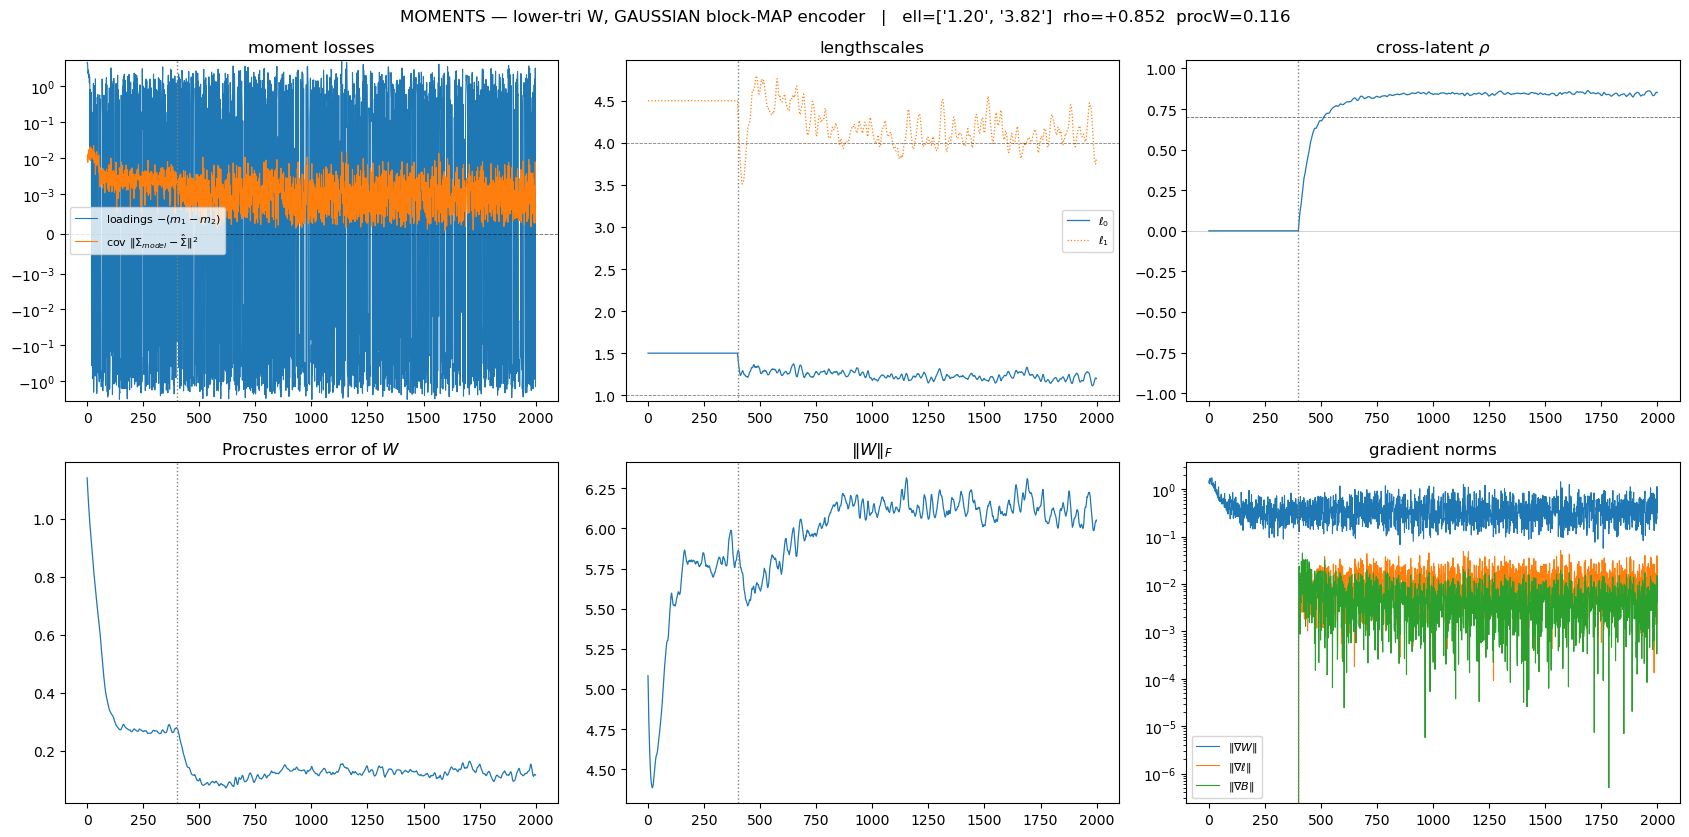

In [7]:
_ = plot_run(Hg, rg, 'MOMENTS — lower-tri W, GAUSSIAN block-MAP encoder')

# Part 2 — lower-tri $W$, **Poisson** block-MAP encoder (Newton)

Swap *only* the encoder for the true Poisson block-MAP. Does the better $z$-imputation tighten
$|\rho|$ onto $0.7$ and pull $\ell_0$ down to $1$?

In [8]:
t0=time.time(); Hp, rp = fit(lower_tri=True, encoder=encode_block_poisson, seed=0); print("poisson lower-tri %.1fs" % (time.time()-t0))
print(f"\nTRUE        ell={ELL_TRUE}  rho={RHO_TRUE}")
print(f"poisson enc ell=[{rp['ell'][0]:.3f},{rp['ell'][1]:.3f}]  rho={rp['rho']:+.3f}  procW={rp['procW']:.3f}")


poisson lower-tri 59.5s

TRUE        ell=[1.0, 4.0]  rho=0.7
poisson enc ell=[1.133,4.140]  rho=-0.829  procW=0.101


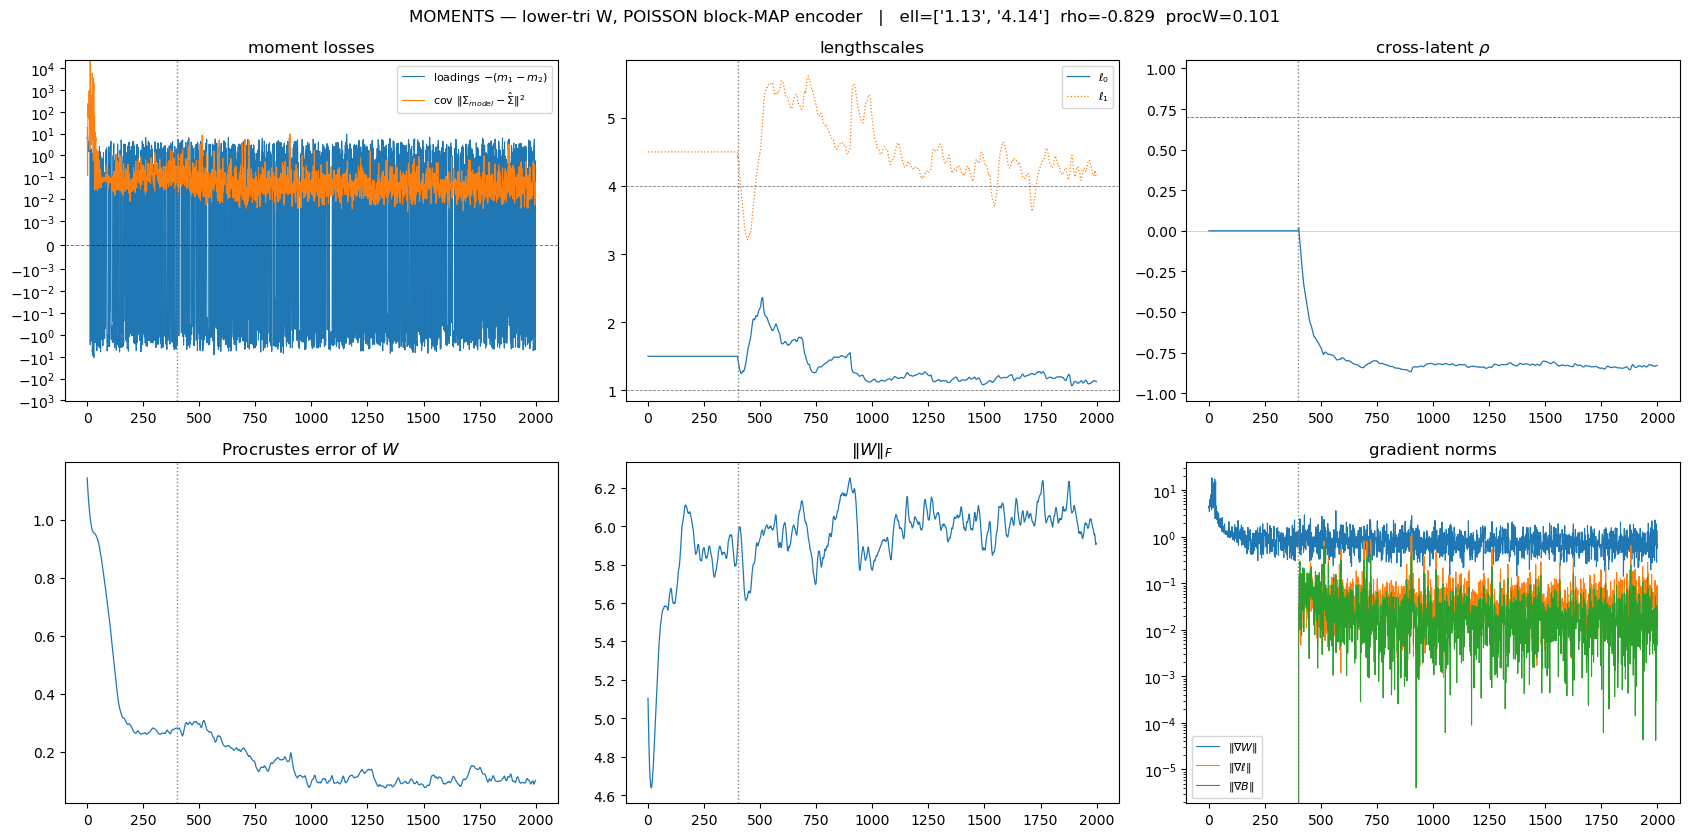

In [9]:
_ = plot_run(Hp, rp, 'MOMENTS — lower-tri W, POISSON block-MAP encoder')

## Robustness across seeds (lower-tri) — Gaussian vs Poisson encoder


In [10]:
print(f"TRUE ell={ELL_TRUE}  rho={RHO_TRUE}\n")
print(f"{'encoder':9s} {'seed':4s} {'ell (sorted)':>16s} {'rho':>8s} {'procW':>8s}")
for tag, enc in [("gauss", encode_block), ("poisson", encode_block_poisson)]:
    for s in range(5):
        _, r = fit(lower_tri=True, encoder=enc, seed=s)
        print(f"{tag:9s} {s:<4d} [{r['ell'][0]:.2f},{r['ell'][1]:.2f}]   {r['rho']:+.3f}   {r['procW']:.3f}", flush=True)


TRUE ell=[1.0, 4.0]  rho=0.7

encoder   seed     ell (sorted)      rho    procW


gauss     0    [1.20,3.82]   +0.852   0.116


gauss     1    [1.22,4.25]   -0.852   0.132


gauss     2    [1.20,4.00]   -0.844   0.116


gauss     3    [1.23,4.19]   -0.856   0.127


...

poisson   0    [1.13,4.14]   -0.829   0.101


poisson   1    [1.18,4.31]   +0.836   0.085


poisson   2    [1.26,3.72]   -0.851   0.149


poisson   3    [1.19,4.32]   +0.841   0.115


poisson   4    [1.23,3.86]   -0.832   0.139
